# LinCodeWeightInv analysis of a saved run

Runs **LinCodeWeightInv** (Pashinska-Gadzheva & Bouyukliev, "Algorithm 1059:
LinCodeWeightInv - Library for Computing the Weight Distribution of Linear
Codes over Finite Fields", *ACM Trans. Math. Softw.* 51(4), Dec 2025) against
`G1` (the generator matrix of `C`) from one saved run in
`06_planted_codeword_repair_isolation/runs/`.

Two things this notebook can do, picked with one boolean flag below:

1. **Weight spectrum** - the full weight distribution `A_0, ..., A_n` of `C`,
   plotted as a bar chart.
2. **Search below target weight** - counts (and, if any exist, dumps) the
   codewords of `C` with weight strictly less than this run's
   `target_weight` (the Gilbert-Varshamov-scaled weight the planted codeword
   `v` was built at - see `planted_codeword_repair_test.py`).

## One-time setup (do this before running the notebook)

LinCodeWeightInv is a C++ library, not a Python package, so it's called
through a small compiled bridge (`LinCodeBridge.cpp`) rather than imported
directly. Two build steps, both one-time - using the library's plain
Makefile rather than CMake, so there's nothing extra to install beyond a
C++ compiler (Xcode Command Line Tools, `xcode-select --install`, if
`g++ --version` doesn't already work):

1. **Check your Mac's architecture first** (this decides which Makefile to
   use):
   ```
   uname -m
   ```
   `arm64` = Apple Silicon (M1/M2/M3/...), `x86_64` = Intel.

2. **Build LinCodeWeightInv itself**, from the library's own root folder
   (the `1059/` folder next to `code/`):
   ```
   cd 1059/Src
   make && make install                          # Intel (x86_64)
   # or, on Apple Silicon (arm64):
   make -f Makefile_neon && make -f Makefile_neon install
   ```
   This produces `1059/Src/lib/LinCodeWeightInv.a` (the static library) and
   `1059/Src/build/Test-UI` (the interactive program from the user manual -
   not used by this notebook, but a good sanity check that the build works).

3. **Build the bridge**, from `1059/Src/testProgram/` (`LinCodeBridge.cpp`
   should already be sitting there):
   ```
   cd 1059/Src/testProgram
   g++ -std=c++17 -O2 -march=native -I../include -o lincode_bridge LinCodeBridge.cpp ../lib/LinCodeWeightInv.a
   ```
   On Apple Silicon, drop `-march=native` (it's an x86-only flag and will
   fail to compile on arm64 - the `Makefile_neon` build above already
   targets NEON instead).

**Why a custom bridge instead of just using LinCodeWeightInv's own file
format?** LinCodeWeightInv's own text-file reader can only parse field
elements up to 2 decimal digits (`< 100`) when `q > 9`. This repo's codes
use `q = 127` (elements 0..126), so its own file reader would silently
corrupt roughly a fifth of the entries in any real matrix here.
`LinCodeBridge.cpp` avoids this entirely by calling LinCodeWeightInv's
in-memory `int**` API directly instead of its file-based API - see the
comment block at the top of `LinCodeBridge.cpp` for the full explanation.


In [18]:
import glob
import os
import subprocess
import tempfile

from sage.all import load

# --- Configuration -----------------------------------------------------

RUNS_DIR = os.path.join('runs')  # relative to this notebook's folder
RUN_ID = "n16_k8_q29_seed6_20260819T013935"  # e.g. 'n128_k64_q127_seed35_20260813T192921'; None = most recent .sobj in RUNS_DIR

# The one boolean asked for: True -> weight spectrum (+ bar plot),
# False -> search for codewords below this run's target_weight.
COMPUTE_WEIGHT_SPECTRUM = True

# Path to the compiled bridge from the "One-time setup" cell above.
LINCODE_BRIDGE = os.path.abspath(os.path.join('..','..', '..', '1059', 'Src', 'testProgram', 'lincode_bridge'))


In [19]:
# Sanity check: the bridge must be built before anything below can run.
if not os.path.isfile(LINCODE_BRIDGE):
    raise FileNotFoundError(
        f"Bridge executable not found at {LINCODE_BRIDGE!r}.\n"
        "Build LinCodeWeightInv and the bridge first - see the setup cell above."
    )
if not os.access(LINCODE_BRIDGE, os.X_OK):
    raise PermissionError(f"{LINCODE_BRIDGE!r} exists but is not executable.")
print(f"Using bridge: {LINCODE_BRIDGE}")


Using bridge: /Users/estefanialaverdebecerra/Documents/GitHubPersonal/PEP-LEP/1059/Src/testProgram/lincode_bridge


## Load the instance

Same pattern as `visualize_runs.ipynb`: pick a `.sobj` (most recent by
default), `load()` it with Sage, and pull out `G1` (generator matrix of
`C`) and this run's `target_weight`.


In [20]:
sobj_paths = sorted(glob.glob(os.path.join(RUNS_DIR, '*.sobj')))
if not sobj_paths:
    raise FileNotFoundError(f"No .sobj files found in {RUNS_DIR}/")

chosen_path = (os.path.join(RUNS_DIR, RUN_ID + '.sobj') if RUN_ID
               else sobj_paths[-1])
print(f"Loading {chosen_path}")
data = load(chosen_path)

params = data['params']
G1 = data['G1']
n, k, q = params['n'], params['k'], params['q']
target_weight = params['target_weight']

print(params)
print(f"G1: {G1.nrows()} x {G1.ncols()} over GF({q})")
print(f"target_weight (this run's planted codeword weight) = {target_weight}")


Loading runs/n16_k8_q29_seed6_20260819T013935.sobj
{'n': 16, 'k': 8, 'q': 29, 'alpha': 0.01, 'beta': 0.08, 'weight_factor': 1.1, 'budgets': 5, 'seed': 6, 'target_weight': 8}
G1: 8 x 16 over GF(29)
target_weight (this run's planted codeword weight) = 8


## Hand G1 to the bridge

Writes `G1` out in the bridge's own simple format (`n k q` on line 1, then
`k*n` whitespace-separated integers - see the comment header in
`LinCodeBridge.cpp`), in a scratch directory so `Result_codewords.txt` /
`error.txt` from the library don't clutter this folder.


In [21]:
scratch_dir = tempfile.mkdtemp(prefix='lincodeweightinv_')
matrix_path = os.path.join(scratch_dir, 'matrix.txt')

with open(matrix_path, 'w') as f:
    f.write(f"{n} {k} {q}\n")
    for row in G1.rows():
        f.write(' '.join(str(int(x)) for x in row) + '\n')

print(f"Scratch dir: {scratch_dir}")
print(f"Matrix file: {matrix_path}")


Scratch dir: /var/folders/dj/ljhjywgx7050wg5x_690yv1c0000gn/T/lincodeweightinv_t2eqzfwv
Matrix file: /var/folders/dj/ljhjywgx7050wg5x_690yv1c0000gn/T/lincodeweightinv_t2eqzfwv/matrix.txt


## Run LinCodeWeightInv

Branches on `COMPUTE_WEIGHT_SPECTRUM` (set in the config cell above).

Note on the "search below target weight" branch: the planted codeword `v`
has weight **exactly** `target_weight`, not less - so it does not itself
count here. A `COUNT` of 0 just means no *other*, lighter codeword happens
to exist in `C`; it is not a sign anything went wrong.


In [22]:
if COMPUTE_WEIGHT_SPECTRUM:
    proc = subprocess.run(
        [LINCODE_BRIDGE, 'spectrum', matrix_path],
        cwd=scratch_dir, capture_output=True, text=True,
    )
    if proc.returncode != 0:
        print(proc.stdout)
        print(proc.stderr)
        raise RuntimeError(f"lincode_bridge exited with code {proc.returncode}")

    lines = proc.stdout.splitlines()
    start = lines.index('===WEIGHTS===') + 1
    end = lines.index('===END===')
    weight_spectrum = {}
    for line in lines[start:end]:
        w_str, count_str = line.split(',')
        weight_spectrum[int(w_str)] = int(count_str)

    nonzero = {w: c for w, c in weight_spectrum.items() if c > 0}
    min_nonzero_weight = min(w for w in nonzero if w > 0)
    print(f"Weight spectrum computed for {len(nonzero)} distinct weights "
          f"(including A_0 = {weight_spectrum[0]}).")
    print(f"Minimum nonzero weight found = {min_nonzero_weight} "
          f"(this run's target_weight = {target_weight})")

else:
    proc = subprocess.run(
        [LINCODE_BRIDGE, 'less_than', matrix_path, str(target_weight)],
        cwd=scratch_dir, capture_output=True, text=True,
    )
    if proc.returncode != 0:
        print(proc.stdout)
        print(proc.stderr)
        raise RuntimeError(f"lincode_bridge exited with code {proc.returncode}")

    lines = proc.stdout.splitlines()
    count_line = next(l for l in lines if l.startswith('COUNT:'))
    count = int(count_line.split(':')[1])

    file_start = lines.index('===CODEWORDS_FILE===') + 1
    file_end = lines.index('===END===')
    codewords_raw = '\n'.join(lines[file_start:file_end])

    print(f"Codewords of weight < {target_weight}: {count}")
    if count > 0:
        print("\nRaw Result_codewords.txt contents "
              "(format documented in LinCodeWeightInv's user manual):\n")
        print(codewords_raw)
    else:
        print("None found below target_weight - only the planted codeword "
              "v (weight == target_weight, not < target_weight) is known "
              "to exist at or below this weight.")


Weight spectrum computed for 10 distinct weights (including A_0 = 0).
Minimum nonzero weight found = 7 (this run's target_weight = 8)


## Weight spectrum bar plot

Only runs when `COMPUTE_WEIGHT_SPECTRUM = True`. Log-scaled y-axis by
default, since weight spectra typically span many orders of magnitude
(a handful of codewords near the minimum distance vs. an enormous count
near weight n/2) - a linear axis would flatten everything except the
tallest bars into invisibility. `target_weight` is marked with a dashed
line for reference against this run's planted codeword.


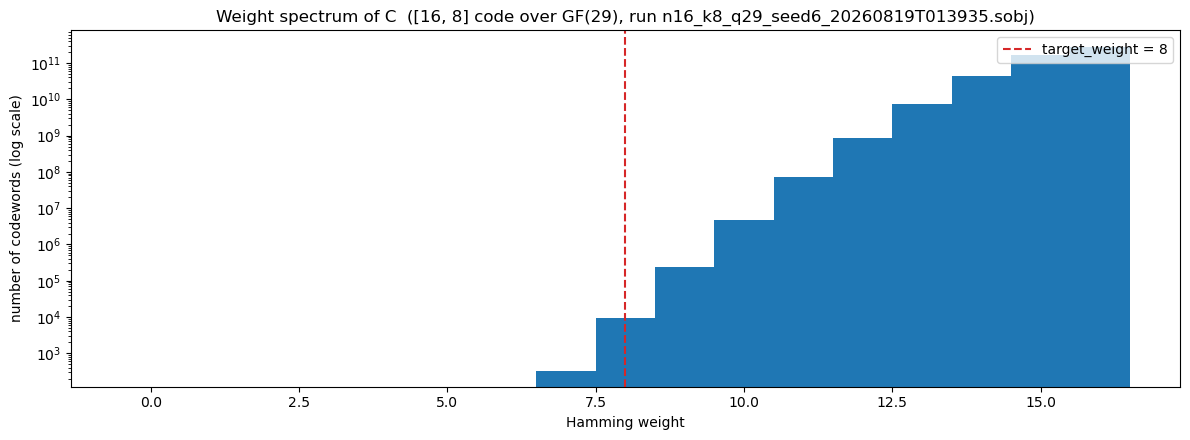

In [23]:
if COMPUTE_WEIGHT_SPECTRUM:
    import matplotlib.pyplot as plt

    weights_sorted = sorted(weight_spectrum)
    counts = [weight_spectrum[w] for w in weights_sorted]

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.bar(weights_sorted, counts, color='tab:blue', width=1.0)
    ax.axvline(target_weight, color='tab:red', linestyle='--', linewidth=1.5,
               label=f'target_weight = {target_weight}')
    ax.set_yscale('log')
    ax.set_xlabel('Hamming weight')
    ax.set_ylabel('number of codewords (log scale)')
    ax.set_title(f'Weight spectrum of C  ([{n}, {k}] code over GF({q}), run {os.path.basename(chosen_path)})')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
else:
    print("COMPUTE_WEIGHT_SPECTRUM is False - set it to True and re-run "
          "the two cells above to see the spectrum + plot.")


## Get a codeword of weight <= target_weight (smaller is better)

Independent of the `COMPUTE_WEIGHT_SPECTRUM` branch above: asks the bridge's
`less_than` mode for every codeword of weight strictly less than
`target_weight + 1` - i.e. weight **<= `target_weight`** - and, among
whatever it finds, keeps the one with the *smallest* weight (a codeword
lighter than `target_weight` is a better result than one sitting exactly
at `target_weight`, e.g. the planted codeword `v` itself). Reuses the same
`less_than` mode used above, just called with `target_weight + 1`, so no
bridge rebuild is needed beyond what "One-time setup" already covers.

In [25]:
proc = subprocess.run(
    [LINCODE_BRIDGE, 'less_than', matrix_path, str(target_weight + 1)],
    cwd=scratch_dir, capture_output=True, text=True,
)
if proc.returncode != 0:
    print(proc.stdout)
    print(proc.stderr)
    raise RuntimeError(f"lincode_bridge exited with code {proc.returncode}")

lines = proc.stdout.splitlines()
count_line = next(l for l in lines if l.startswith('COUNT:'))
count_at_most_target = int(count_line.split(':')[1])

file_start = lines.index('===CODEWORDS_FILE===') + 1
file_end = lines.index('===END===')
codewords_raw = '\n'.join(lines[file_start:file_end])

print(f"Codewords of weight <= {target_weight}: {count_at_most_target}")

# Result_codewords.txt: two header lines ("n = .., k = .., q = .." and
# "Searching for words with weight < ..:"), then one line per codeword -
# n comma-separated field values, e.g. "0, 5, 12, ..., 3, "
codeword_lines = [
    l for l in codewords_raw.splitlines()
    if l.strip() and not l.startswith('n = ') and not l.strip().startswith('Searching')
]

candidates = []
for line in codeword_lines:
    parts = [p.strip() for p in line.split(',') if p.strip() != '']
    if len(parts) != n:
        continue
    cw = vector(GF(q), [int(p) % q for p in parts])
    w = sum(1 for x in cw if x != 0)
    candidates.append((w, cw))

if candidates:
    best_weight, best_codeword = min(candidates, key=lambda t: t[0])
    print(f"\nLightest codeword found (weight {best_weight}, "
          f"target_weight = {target_weight}):")
    print(best_codeword)
    assert best_weight <= target_weight, (
        f"parsed codeword has weight {best_weight} > target_weight "
        f"{target_weight} - check Result_codewords.txt's format hasn't changed"
    )
else:
    print("\nNo codeword of weight <= target_weight could be parsed out of "
          "Result_codewords.txt - raw contents:\n")
    print(codewords_raw)

Codewords of weight <= 8: 9940

Lightest codeword found (weight 7, target_weight = 8):
(0, 5, 0, 0, 7, 20, 0, 0, 27, 0, 2, 0, 0, 3, 21, 0)
